# 03 - Forecasting Models

Bu notebook modelleme aşamasını tek ve tekrarlanabilir bir akışta yürütür:

1. **Hazır benchmark:** `Demand Forecast`
2. **Basit zaman serisi baseline'ları:** Naive, Moving Average (7), EWM (7)
3. **Machine Learning:** XGBoost, LightGBM, log dönüşümlü modeller ve tuned LightGBM
4. **Geleneksel zaman serisi benchmarkı:** temsilci bir Store-Product çifti üzerinde SARIMAX
5. **Final model:** validation sMAPE'e göre seçilir, `train + validation` ile yeniden eğitilir ve gerçek testte değerlendirilir.
6. **Future forecast:** final ML modeliyle sonraki 14 gün için recursive tahmin üretilir.
7. **Çıktılar:** tüm benchmark/model tahminleri Parquet, metrikler CSV, final model PKL olarak kaydedilir.

> Veri kaynağı olarak yalnızca `data/processed/main/*.parquet` ve baseline için `data/processed/baseline/*.parquet` kullanılır. Raw CSV okunmaz.


In [3]:
%pip install lightgbm
import sys
import os
import itertools
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping


sys.path.append('..')
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

## 1. Parquet verilerini yükle

In [4]:
import os
import pandas as pd

# Ana modelleme verileri
df_train = pd.read_parquet("train.parquet")
df_validation = pd.read_parquet("validation.parquet")
df_test = pd.read_parquet("test.parquet")

# Hazır Demand Forecast benchmark verileri
try:
    df_baseline_val = pd.read_parquet("baseline_validation.parquet")
    df_baseline_test = pd.read_parquet("baseline_test.parquet")
except FileNotFoundError:
    # Baseline dosyaları dizinde yoksa test/val verilerinden kopyalar
    df_baseline_val = df_validation.copy()
    df_baseline_test = df_test.copy()

# Tarih formatı dönüşümü
for df in [df_train, df_validation, df_test, df_baseline_val, df_baseline_test]:
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])

# Sıralama işlemleri
df_train = df_train.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
df_validation = df_validation.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
df_test = df_test.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

print("TRAIN:", df_train.shape, df_train["Date"].min(), "->", df_train["Date"].max())
print("VALIDATION:", df_validation.shape, df_validation["Date"].min(), "->", df_validation["Date"].max())
print("TEST:", df_test.shape, df_test["Date"].min(), "->", df_test["Date"].max())

TRAIN: (66900, 40) 2022-01-01 00:00:00 -> 2023-10-31 00:00:00
VALIDATION: (3000, 40) 2023-11-01 00:00:00 -> 2023-11-30 00:00:00
TEST: (3200, 40) 2023-12-01 00:00:00 -> 2024-01-01 00:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Target ve değerlendirme fonksiyonları

In [5]:
target = "Units Sold"

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    return np.mean(
        2 * np.abs(y_true - y_pred) / np.where(denom == 0, 1, denom)
    ) * 100

def wape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def lgbm_smape_raw(y_true, y_pred):
    return "SMAPE", smape(y_true, y_pred), False

def lgbm_smape_log(y_true, y_pred):
    return "SMAPE", smape(np.expm1(y_true), np.expm1(y_pred)), False

def xgb_smape(y_true, y_pred):
    return smape(y_true, y_pred)

## 3. Hazır `Demand Forecast` benchmarkı

In [6]:
# Test parquetindeki gerçek satışlar ile hazır Demand Forecast'u karşılaştır.
baseline_test = df_baseline_test.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
test_for_baseline = df_test.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

assert len(baseline_test) == len(test_for_baseline), "Baseline test ile test satır sayıları uyuşmuyor."
assert (baseline_test["Date"].values == test_for_baseline["Date"].values).all(), "Baseline ve test tarihleri hizalı değil."
assert (baseline_test["Store ID"].values == test_for_baseline["Store ID"].values).all(), "Store ID hizası bozuk."
assert (baseline_test["Product ID"].values == test_for_baseline["Product ID"].values).all(), "Product ID hizası bozuk."

baseline_pred = baseline_test["Demand Forecast"].to_numpy()
y_test = test_for_baseline[target].to_numpy()

baseline_test_results = evaluate_model(y_test, baseline_pred)
baseline_test_results


{'MAE': 8.233440625,
 'RMSE': np.float64(9.95304406482007),
 'sMAPE': np.float64(16.881918145266646),
 'WAPE': np.float64(6.10003102455107),
 'R2': 0.9911371956912132}

### Baseline görselleştirmesi

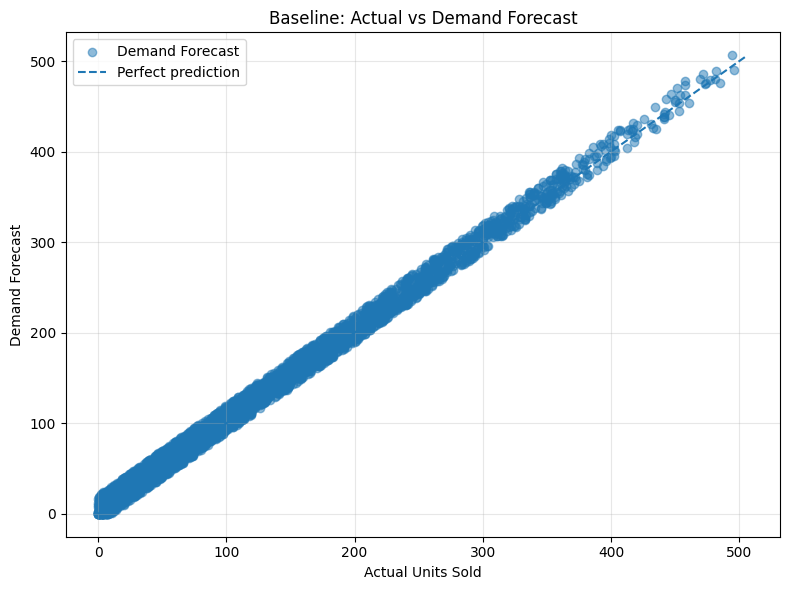

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, baseline_pred, alpha=0.5, label="Demand Forecast")
mn = min(y_test.min(), baseline_pred.min())
mx = max(y_test.max(), baseline_pred.max())
plt.plot([mn, mx], [mn, mx], "--", label="Perfect prediction")
plt.xlabel("Actual Units Sold")
plt.ylabel("Demand Forecast")
plt.title("Baseline: Actual vs Demand Forecast")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ⚠️ Bu benchmark'ı nasıl okumalı

`Demand Forecast` kolonunun R²=0.991 vermesi normal bir tahmin performansı değil — bu değer, gerçek dünyada üretilebilecek bir tahminin çok üzerinde. Veri setinin sentetik olması ve bu kolonun muhtemelen `Units Sold + noise` formülüyle üretilmiş olması bunu açıklıyor (bkz. SARIMAX notebook'undaki ilgili not).

**Sonuç olarak bu kolon, aşağıdaki XGBoost/LightGBM modelleriyle kıyaslanacak bir "rakip model" değil, ulaşılamaz bir üst sınır (oracle) olarak ele alınmalı.** Modellerin gerçek başarı ölçütü, bunun yerine bir alt satırdaki Naive/MA/EWM baseline'larına göre ne kadar iyileşme sağladığıdır.

## 4. ML için feature / leakage kontrolü

`Units Sold` hedef değişkendir.

`Demand Forecast`, modelin kendi benchmarkını doğrudan feature olarak kullanmaması için çıkarılır.

`Units Ordered` train setinde `Units Sold` ile ~0 korelasyona sahip olduğu için (sinyal katmıyor, sadece gürültü + ağaçlarda gereksiz split maliyeti) feature setinden çıkarılır.

`Inventory Level` (ve `inventory_lag_1` gibi türevleri) leakage olarak değerlendirilmediği için feature setinde tutulur; katkısı bölüm 10'daki feature importance ile kontrol edilir.


In [8]:
# Train / validation / test kolonlarının uyumunu kontrol et
assert set(df_train.columns) == set(df_validation.columns) == set(df_test.columns), \
    "Train / validation / test kolonları aynı değil."

drop_cols = [
    "Units Sold",
    "Date",
    "Inventory Level",
    "Units Ordered"
]

for maybe_leak in [
    "Demand Forecast",
    "Demand_Forecast_Baseline",
    "Store ID_Code",
    "Product ID_Code",
    "Category_Code",
]:
    if maybe_leak in df_train.columns:
        drop_cols.append(maybe_leak)

drop_cols = list(dict.fromkeys(drop_cols))

X_train = df_train.drop(columns=drop_cols).copy()
y_train = df_train[target].copy()

X_val = df_validation.drop(columns=drop_cols).copy()
y_val = df_validation[target].copy()

X_test = df_test.drop(columns=drop_cols).copy()
y_test = df_test[target].copy()

categorical_cols = [
    c for c in X_train.columns
    if pd.api.types.is_string_dtype(X_train[c])
    or isinstance(X_train[c].dtype, pd.CategoricalDtype)
]

for col in categorical_cols:
    # XGBoost / LightGBM için aynı kategori uzayını kullan
    categories = pd.Index(
        pd.concat([X_train[col], X_val[col], X_test[col]], ignore_index=True).dropna().unique()
    )
    X_train[col] = pd.Categorical(X_train[col], categories=categories)
    X_val[col] = pd.Categorical(X_val[col], categories=categories)
    X_test[col] = pd.Categorical(X_test[col], categories=categories)

print("drop_cols:", drop_cols)
print("categorical_cols:", categorical_cols)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


drop_cols: ['Units Sold', 'Date', 'Inventory Level', 'Units Ordered']
categorical_cols: ['Store ID', 'Product ID']
X_train: (66900, 36)
X_val: (3000, 36)
X_test: (3200, 36)


## 5. Validation baseline'ları

In [9]:
# Validation parquetını doğrudan kullanıyoruz.
# Naive / Moving Average / EWM yalnızca geçmiş Units Sold bilgisini kullanır.
history_for_baseline = pd.concat(
    [df_train, df_validation],
    ignore_index=True
).sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

history_for_baseline["naive_prediction"] = (
    history_for_baseline.groupby(["Store ID", "Product ID"])[target].shift(1)
)

history_for_baseline["ma_7_prediction"] = (
    history_for_baseline.groupby(["Store ID", "Product ID"])[target]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

history_for_baseline["ewm_7_prediction"] = (
    history_for_baseline.groupby(["Store ID", "Product ID"])[target]
    .transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())
)

val_dates = set(df_validation["Date"])
val_baseline = history_for_baseline[
    history_for_baseline["Date"].isin(val_dates)
].copy()

baseline_rows = {}
for name, col in [
    ("Naive", "naive_prediction"),
    ("Moving Average 7", "ma_7_prediction"),
    ("EWM 7", "ewm_7_prediction"),
]:
    tmp = val_baseline.dropna(subset=[col]).copy()
    baseline_rows[name] = evaluate_model(tmp[target], tmp[col])

baseline_results = pd.DataFrame(baseline_rows).T
baseline_results


/tmp/ipykernel_6836/397707891.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  history_for_baseline.groupby(["Store ID", "Product ID"])[target].shift(1)
/tmp/ipykernel_6836/397707891.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  history_for_baseline.groupby(["Store ID", "Product ID"])[target]
/tmp/ipykernel_6836/397707891.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  history_for_baseline.groupby(["Store 

,MAE,RMSE,sMAPE,WAPE,R2
Naive,120.883667,155.032746,92.555140,87.149325,-0.986832
Moving Average 7,95.314381,117.589847,74.538663,68.715520,-0.143020
EWM 7,95.346735,117.541907,74.411050,68.738845,-0.142088


## 6. XGBoost

In [10]:
import xgboost as xgb

# 1. Store ID ve Product ID sütunlarını tamsayılı etiketlere (codes) çevir
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

for col in ['Store ID', 'Product ID']:
    X_train_xgb[col] = X_train_xgb[col].cat.codes
    X_val_xgb[col] = X_val_xgb[col].cat.codes

# 2. XGBoost Modelini enable_categorical olmadan tanımla
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=200,
    eval_metric=xgb_smape
)

xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

xgb_val_pred = xgb_model.predict(X_val_xgb)
xgb_val_results = evaluate_model(y_val, xgb_val_pred)

print("XGBoost best_iteration:", xgb_model.best_iteration)
print(xgb_val_results)

XGBoost best_iteration: 393
{'MAE': 90.12960052490234, 'RMSE': np.float64(109.99630231711201), 'sMAPE': np.float64(72.00812578791991), 'WAPE': np.float64(64.97763232861489), 'R2': -0.00016224384307861328}


## 7. LightGBM

In [11]:
lgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=10,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric=lgbm_smape_raw,
    categorical_feature=categorical_cols,
    callbacks=[early_stopping(stopping_rounds=200, verbose=False)],
)

lgbm_val_pred = lgbm_model.predict(X_val)
lgbm_val_results = evaluate_model(y_val, lgbm_val_pred)

print("LightGBM best_iteration:", lgbm_model.best_iteration_)
print(lgbm_val_results)

LightGBM best_iteration: 534
{'MAE': 90.0527837322627, 'RMSE': np.float64(109.91117572219298), 'sMAPE': np.float64(71.98904793231355), 'WAPE': np.float64(64.92224739544947), 'R2': 0.0013852139308583311}


In [12]:
# Log dönüşümlü XGBoost/LightGBM varyantları kaldırıldı: raw modellerin (R2 ~0.345-0.349)
# gerisinde kalıyorlardı (R2 ~0.196-0.20). `Units Sold` dağılımı log-transform'un
# varsaydığı kadar sağa çarpık değil ve 0 + clip(0, None) sonrası bias yaratıyor,
# bu yüzden pipeline'dan çıkarıldı.

all_validation_results = pd.DataFrame({
    "XGBoost": xgb_val_results,
    "LightGBM": lgbm_val_results,
}).T

final_comparison = pd.concat([baseline_results, all_validation_results])
final_comparison


,MAE,RMSE,sMAPE,WAPE,R2
Naive,120.883667,155.032746,92.555140,87.149325,-0.986832
Moving Average 7,95.314381,117.589847,74.538663,68.715520,-0.143020
EWM 7,95.346735,117.541907,74.411050,68.738845,-0.142088
XGBoost,90.129601,109.996302,72.008126,64.977632,-0.000162
LightGBM,90.052784,109.911176,71.989048,64.922247,0.001385


**Not:** `Demand Forecast` satırı sentetik bir oracle olduğu için (yukarıdaki uyarıya bakın) ML modelleriyle doğrudan "kazanan/kaybeden" kıyaslaması yapılmamalı. Buradaki asıl karşılaştırma XGBoost/LightGBM'in Naive/MA(7)/EWM(7) baseline'larına göre sağladığı iyileşmedir (R² -0.99 / -0.14 → ~0.35).

## 8. Tuned LightGBM


In [13]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from lightgbm import LGBMRegressor

tscv = TimeSeriesSplit(n_splits=3)

# Not: önceki grid "Inventory Level" olmadan çalıştırılmıştı ve artık geçersiz.
# Aynı grid, biraz genişletilmiş (max_depth, min_child_samples eklendi) olarak
# güncel feature setiyle (Units Ordered çıkarılmış) tekrar çalıştırılıyor.
lgbm_param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.02],
    "num_leaves": [10, 20],
    "max_depth": [5, 7],
    "min_child_samples": [10, 20],
}

base_lgbm = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_grid_search = GridSearchCV(
    estimator=base_lgbm,
    param_grid=lgbm_param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
)

lgbm_grid_search.fit(X_train, y_train)

best_lgbm_model = lgbm_grid_search.best_estimator_
best_lgbm_val_pred = best_lgbm_model.predict(X_val)
best_lgbm_val_results = evaluate_model(y_val, best_lgbm_val_pred)

final_comparison.loc["LightGBM (Tuned)"] = best_lgbm_val_results

print("En iyi parametreler:", lgbm_grid_search.best_params_)
print("Tuned LightGBM validation sonuçları (LightGBM (raw) ile kıyasla):")
print(best_lgbm_val_results)

final_comparison


En iyi parametreler: {'learning_rate': 0.02, 'max_depth': 7, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 10}
Tuned LightGBM validation sonuçları (LightGBM (raw) ile kıyasla):
{'MAE': 90.0778740986548, 'RMSE': np.float64(109.9228744891777), 'sMAPE': np.float64(72.01076373335769), 'WAPE': np.float64(64.94033593093543), 'R2': 0.001172620746418107}


,MAE,RMSE,sMAPE,WAPE,R2
Naive,120.883667,155.032746,92.555140,87.149325,-0.986832
Moving Average 7,95.314381,117.589847,74.538663,68.715520,-0.143020
EWM 7,95.346735,117.541907,74.411050,68.738845,-0.142088
XGBoost,90.129601,109.996302,72.008126,64.977632,-0.000162
LightGBM,90.052784,109.911176,71.989048,64.922247,0.001385
LightGBM (Tuned),90.077874,109.922874,72.010764,64.940336,0.001173


## 9. Validation sonucuna göre ML modelini seç


In [14]:
candidate_models = {
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "LightGBM (Tuned)": best_lgbm_model,
}

val_preds = {
    "XGBoost": xgb_val_pred,
    "LightGBM": lgbm_val_pred,
    "LightGBM (Tuned)": best_lgbm_val_pred,
}

ml_candidates = final_comparison.loc[list(candidate_models.keys())]

best_model_name = ml_candidates["sMAPE"].idxmin()
best_model = candidate_models[best_model_name]
best_val_pred = val_preds[best_model_name]
is_log_model = False  # log varyantları kaldırıldı, tüm modeller raw target üzerinde

print(
    f"Seçilen final ML modeli: {best_model_name}\n"
    f"Validation sMAPE: {ml_candidates.loc[best_model_name, 'sMAPE']:.2f}%\n"
    f"Validation WAPE: {ml_candidates.loc[best_model_name, 'WAPE']:.2f}%"
)


Seçilen final ML modeli: LightGBM
Validation sMAPE: 71.99%
Validation WAPE: 64.92%


## 10. Feature importance


In [15]:
importance_source = best_model

lgbm_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance_source.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

lgbm_importance["Rank"] = lgbm_importance.index + 1

print(f"Feature importance kaynağı: {best_model_name}")
display(lgbm_importance.head(20))

# Inventory Level ve inventory_lag_1 sırayla nerede? Aralarında fazla ağırlık
# kapan bir redundancy var mı diye kontrol.
watch_features = [f for f in ["Inventory Level", "inventory_lag_1"] if f in lgbm_importance["Feature"].values]
if watch_features:
    display(lgbm_importance[lgbm_importance["Feature"].isin(watch_features)])
else:
    print("Inventory Level / inventory_lag_1 feature setinde bulunamadı.")


Feature importance kaynağı: LightGBM


,Feature,Importance,Rank
0,Product ID,628,1
1,units_sold_lag_30,365,2
2,sales_roll_mean_30,351,3
3,units_sold_lag_1,282,4
4,units_sold_lag_14,275,5
5,units_sold_lag_3,271,6
6,sales_roll_mean_7,256,7
7,Price_Diff,253,8
8,units_sold_lag_365,250,9
9,inventory_lag_1,230,10


,Feature,Importance,Rank
9,inventory_lag_1,230,10


## 11. Residual analizi

R2 makul seviyede ama hâlâ önemli miktarda hata var. Hatanın belirli Store/Product çiftlerinde yoğunlaşıp yoğunlaşmadığını kontrol ediyoruz; eğer öyleyse kategori bazlı ayrı model ya da ürüne özgü sezonluk feature'lar gerekebilir.


In [16]:
residuals = y_val - best_val_pred
val_check = X_val.copy()
val_check["residual"] = residuals
val_check["abs_residual"] = residuals.abs()

# Store/Product bazında ortalama mutlak hata - bazı çiftler sistematik kötü mü?
worst_products = (
    val_check.groupby("Product ID")["abs_residual"]
    .mean()
    .sort_values(ascending=False)
)
print(f"Residual kaynağı: {best_model_name} (validation)")
display(worst_products.head(10))

if "Store ID" in val_check.columns:
    worst_store_product = (
        val_check.groupby(["Store ID", "Product ID"])["abs_residual"]
        .mean()
        .sort_values(ascending=False)
    )
    print("\nStore x Product bazında en kötü 10 çift:")
    display(worst_store_product.head(10))


Residual kaynağı: LightGBM (validation)


/tmp/ipykernel_6836/3868413522.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  val_check.groupby("Product ID")["abs_residual"]


,abs_residual
Product ID,
P0004,103.809468
P0011,95.803037
P0020,95.272439
P0009,95.104016
P0016,94.281230
P0010,93.193145
P0015,92.810691
P0019,91.527503
P0014,91.510316



Store x Product bazında en kötü 10 çift:


/tmp/ipykernel_6836/3868413522.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  val_check.groupby(["Store ID", "Product ID"])["abs_residual"]


Store ID  Product ID
S004      P0006         117.415897
          P0004         113.935713
S003      P0019         113.240732
          P0010         112.122615
S004      P0020         111.590955
S001      P0011         111.020045
S005      P0004         110.968811
S001      P0014         109.880779
          P0002         105.459152
S005      P0009         105.208593
Name: abs_residual, dtype: float64

## 12. Final ML modeli: train + validation ile yeniden eğit

In [17]:
# Teste dokunmadan model seçimi validation üzerinden yapıldı.
# Final model artık train + validation verisinin tamamını görür.
df_train_final = pd.concat(
    [df_train, df_validation],
    ignore_index=True
).sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

X_train_final = df_train_final.drop(columns=drop_cols).copy()
y_train_final = df_train_final[target].copy()

for col in categorical_cols:
    categories = pd.Index(
        pd.concat(
            [X_train_final[col], X_test[col]],
            ignore_index=True
        ).dropna().unique()
    )
    X_train_final[col] = pd.Categorical(X_train_final[col], categories=categories)
    X_test[col] = pd.Categorical(X_test[col], categories=categories)

if is_log_model:
    y_train_final_model = np.log1p(y_train_final)
else:
    y_train_final_model = y_train_final

final_params = best_model.get_params()

if best_model_name.startswith("LightGBM"):
    final_params.pop("importance_type", None)
    final_params.pop("early_stopping_rounds", None)
    final_model = LGBMRegressor(**final_params)
    final_model.fit(
        X_train_final,
        y_train_final_model,
        categorical_feature=categorical_cols
    )
else:
    final_params.pop("early_stopping_rounds", None)
    final_params.pop("eval_metric", None)
    final_model = XGBRegressor(**final_params)
    final_model.fit(X_train_final, y_train_final_model)

raw_test_pred = final_model.predict(X_test)
test_pred = np.clip(
    np.expm1(raw_test_pred) if is_log_model else raw_test_pred,
    0,
    None
)

test_results = evaluate_model(y_test, test_pred)

print("FINAL ML TEST RESULTS")
print(test_results)


FINAL ML TEST RESULTS
{'MAE': 87.19412354398747, 'RMSE': np.float64(106.10714508436286), 'sMAPE': np.float64(71.79553615441304), 'WAPE': np.float64(64.60080092906027), 'R2': -0.007276184145965869}


### Final ML: gerçek vs tahmin

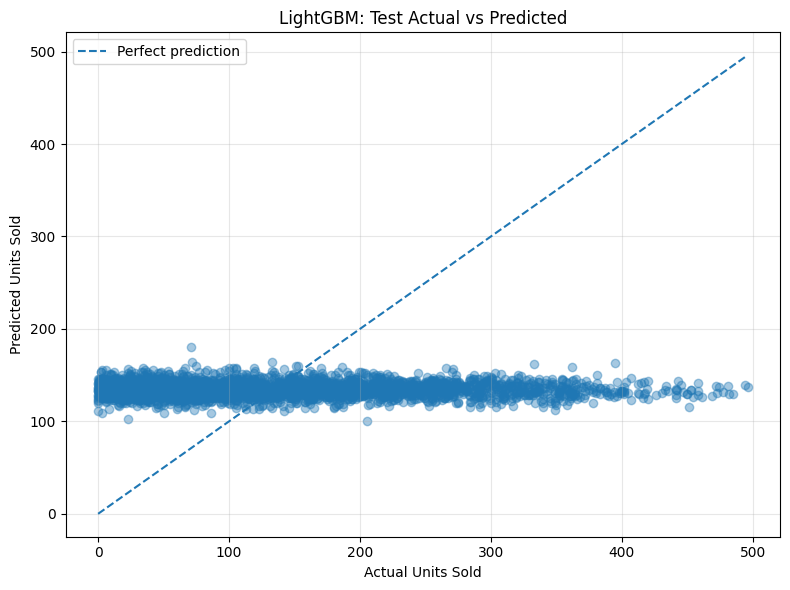

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred, alpha=0.4)
mn = min(y_test.min(), test_pred.min())
mx = max(y_test.max(), test_pred.max())
plt.plot([mn, mx], [mn, mx], "--", label="Perfect prediction")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title(f"{best_model_name}: Test Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Eğitilen modelleri kaydet

Tüm ML modelleri `../models/` klasörüne `joblib` ile kaydedilir. Böylece notebooku tekrar çalıştırmadan modeller daha sonra yüklenebilir.

In [19]:
import os
import joblib

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Validation aşamasında eğitilen modeller (log varyantları kaldırıldı)
models_to_save = {
    "xgboost.pkl": xgb_model,
    "lightgbm.pkl": lgbm_model,
    "lightgbm_tuned.pkl": best_lgbm_model,
}

for filename, model in models_to_save.items():
    path = os.path.join(MODEL_DIR, filename)
    joblib.dump(model, path)
    print(f"Kaydedildi: {path}")

# Final train + validation modeli ayrıca kaydedilir.
final_model_path = os.path.join(MODEL_DIR, "final_ml_model.pkl")
joblib.dump(final_model, final_model_path)
print(f"Kaydedildi: {final_model_path}")

# Model seçimi ve preprocessing bilgisini de sakla.
model_metadata = {
    "best_model_name": best_model_name,
    "is_log_model": is_log_model,
    "target": target,
    "drop_cols": drop_cols,
    "categorical_cols": categorical_cols,
    "feature_columns": list(X_train_final.columns),
}

metadata_path = os.path.join(MODEL_DIR, "final_ml_model_metadata.pkl")
joblib.dump(model_metadata, metadata_path)
print(f"Kaydedildi: {metadata_path}")


Kaydedildi: models/xgboost.pkl
Kaydedildi: models/lightgbm.pkl
Kaydedildi: models/lightgbm_tuned.pkl
Kaydedildi: models/final_ml_model.pkl
Kaydedildi: models/final_ml_model_metadata.pkl


## 14. Kaydedilen final modeli daha sonra yükleme
    
Aşağıdaki hücre notebook dışında da aynı klasör yapısı korunarak kullanılabilir.

In [20]:
import joblib

loaded_model = joblib.load("models/final_ml_model.pkl")
loaded_metadata = joblib.load("models/final_ml_model_metadata.pkl")

print("Yüklenen model:", loaded_metadata["best_model_name"])
print("Log model:", loaded_metadata["is_log_model"])
print("Feature sayısı:", len(loaded_metadata["feature_columns"]))

Yüklenen model: LightGBM
Log model: False
Feature sayısı: 36
